# MOUNTING DRIVE AND USING DATASETS

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
seed_path = '/content/drive/MyDrive/ER/SEED_IV/'
ravdess_path = '/content/drive/MyDrive/ER/RAVDESS/'

# IMPORTING LIBRARIES


In [ ]:
!pip install mne librosa torch torchaudio scikit-learn matplotlib seaborn scipy

import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import mne
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from scipy.io import loadmat
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split


# 1. EEG Branch Architecture and Data Augmentation
In this section, we define the EEG-specific components of our hybrid model. The EEG branch processes Differential Entropy features across five frequency bands (310-d vectors) using a 1D CNN for local feature extraction and a Bi-LSTM for temporal modeling.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- EEG DATA AUGMENTATION ---
def apply_eeg_aug(data):
    """
    Applies Gaussian noise and channel dropout to EEG Differential Entropy features.
    """
    # Add Gaussian Noise
    if random.random() > 0.5:
        data += np.random.normal(0, 0.01, data.shape)
    # Random Channel Dropout (setting 10% of features to zero)
    if random.random() > 0.5:
        idx = np.random.choice(data.shape[0], int(data.shape[0]*0.1), replace=False)
        data[idx] = 0
    return data

# --- EEG BRANCH MODEL ---
class EEGBranch(nn.Module):
    def __init__(self):
        super(EEGBranch, self).__init__()
        # Input shape: (Batch, 1, 310)
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # Bi-LSTM expects (Batch, Seq, Hidden)
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            dropout=0.3,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, x):
        # x: (Batch, 310) -> (Batch, 1, 310)
        x = x.unsqueeze(1)
        x = self.cnn(x)

        # Reshape for LSTM: (Batch, Channels, Seq) -> (Batch, Seq, Channels)
        x = x.transpose(1, 2)

        # Bi-LSTM output
        _, (h, _) = self.lstm(x)

        # Concatenate final forward and backward hidden states (2 * 128 = 256-d)
        # h shape: (num_layers * num_directions, batch, hidden_size)
        # We take the last layer's forward and backward states
        out = torch.cat((h[-2,:,:], h[-1,:,:]), dim=1)
        return out

print("EEG Branch and Augmentation logic initialized.")

EEG Branch and Augmentation logic initialized.


#2. Multi-Modal Dataset and Preprocessing
This class handles the loading of both EEG features and Audio paths, ensuring they are aligned for the late-fusion training process.

In [ ]:
class MultiModalDataset(Dataset):
    def __init__(self, eeg_data, audio_paths, eeg_labels, audio_labels, transform=True):
        self.eeg_data = eeg_data
        self.audio_paths = audio_paths
        self.eeg_labels = eeg_labels
        self.audio_labels = audio_labels
        self.transform = transform

    def __len__(self):
        return len(self.eeg_data)

    def __getitem__(self, idx):
        # 1. Process EEG
        eeg = self.eeg_data[idx].copy()
        if self.transform:
            eeg = apply_eeg_aug(eeg)
        eeg_tensor = torch.FloatTensor(eeg)

        # 2. Process Audio Placeholder (to be expanded in next steps
        return eeg_tensor, self.audio_paths[idx], self.eeg_labels[idx], self.audio_labels[idx]

print("Dataset loader defined.")

Dataset loader defined.


#3. Audio Branch Architecture and Data Augmentation
The audio branch takes mel-spectrograms as input. We use a 2D CNN with Global Average Pooling (GAP) to condense spatial features before passing them to a Bi-LSTM for sequence modeling.

In [ ]:
#  AUDIO DATA AUGMENTATION
def apply_audio_aug(y, sr):

    #Applies time-stretching and pitch-shifting to raw audio signals.

    if random.random() > 0.5:
        rate = random.uniform(0.8, 1.2)
        y = librosa.effects.time_stretch(y, rate=rate)
    if random.random() > 0.5:
        steps = random.uniform(-2, 2)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
    return y

#  AUDIO BRANCH MODEL --
class AudioBranch(nn.Module):
    def __init__(self):
        super(AudioBranch, self).__init__()
        # Input shape: (Batch, 1, 128, Seq_Len)
        self.cnn2d = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        # Global Average Pooling along the frequency dimension
        self.gap = nn.AdaptiveAvgPool2d((1, None))

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            dropout=0.3,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, x):
        # CNN extract features
        x = self.cnn2d(x)

        # Condense frequency dim: (Batch, 128, 1, Seq_reduced)
        x = self.gap(x)

        # Reshape for LSTM: (Batch, Seq_reduced, 128)
        x = x.squeeze(2).transpose(1, 2)

        _, (h, _) = self.lstm(x)

        # Concatenate final forward/backward states (256-d)
        out = torch.cat((h[-2,:,:], h[-1,:,:]), dim=1)
        return out

print("Audio Branch and Augmentation logic initialized.")

Audio Branch and Augmentation logic initialized.


# 4. Hybrid Model (Late Fusion)
This final architecture combines the EEG and Audio embeddings. We use a shared fully connected layer before splitting into two separate output heads to accommodate the different number of classes in each dataset.

In [ ]:
class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()
        self.eeg_branch = EEGBranch()
        self.audio_branch = AudioBranch()

        # Fusion Layer: Concatenated 256 + 256 = 512
        self.fusion = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # SEED-IV Output Head (4 classes)
        self.seed_head = nn.Linear(256, 4)

        # RAVDESS Output Head (8 classes)
        self.ravdess_head = nn.Linear(256, 8)

    def forward(self, eeg_data, audio_data):
        # Extract embeddings
        eeg_emb = self.eeg_branch(eeg_data)
        audio_emb = self.audio_branch(audio_data)

        # Late Fusion via Concatenation
        combined = torch.cat((eeg_emb, audio_emb), dim=1)

        # Pass through fusion layers
        fused_feat = self.fusion(combined)

        # Multi-task output
        seed_logits = self.seed_head(fused_feat)
        ravdess_logits = self.ravdess_head(fused_feat)

        return seed_logits, ravdess_logits

model = HybridModel().to(device)
print("Hybrid Model with Late Fusion and Multi-task heads initialized.")

Hybrid Model with Late Fusion and Multi-task heads initialized.


# 5. Training Strategy: Multi-task Loss and Optimizer
We implement a dual-loss objective where the total loss is a weighted average (0.5 each) of the Cross-Entropy losses from both tasks. Label smoothing is applied to improve generalization.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50):
    # Loss: Cross-Entropy with 0.1 Label Smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Optimizer: Adam with Weight Decay
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Scheduler: Cosine Annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'seed_acc': [], 'ravdess_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for eeg, audio, seed_lab, rav_lab in train_loader:
            eeg, audio = eeg.to(device), audio.to(device)
            seed_lab, rav_lab = seed_lab.to(device), rav_lab.to(device)

            optimizer.zero_grad()

            # Forward pass
            seed_out, rav_out = model(eeg, audio)

            # Calculate weighted loss
            loss_seed = criterion(seed_out, seed_lab)
            loss_rav = criterion(rav_out, rav_lab)
            loss = 0.5 * loss_seed + 0.5 * loss_rav

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    return history

print("Training loop with Dual-Loss and Label Smoothing ready.")

Training loop with Dual-Loss and Label Smoothing ready.


In [ ]:

X = torch.randn(100, 20)   # 100 samples, 20 features
y = torch.randint(0, 2, (100,))  # Binary labels (AD / Non-AD)

# Neural Network Model
class ADModel(nn.Module):
    def __init__(self):
        super(ADModel, self).__init__()
        self.fc1 = nn.Linear(20, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = ADModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
for epoch in range(50):
    optimizer.zero_grad()

    outputs = model(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.6836
Epoch 20, Loss: 0.6675
Epoch 30, Loss: 0.6506
Epoch 40, Loss: 0.6304
Epoch 50, Loss: 0.6046


# 6. Training Execution and Results Visualization
This section defines the training loop and triggers the multi-modal training process using the SEED-IV and RAVDESS datasets.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'seed_acc': [], 'ravdess_acc': []}

    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for eeg, audio, seed_lab, rav_lab in train_loader:
            eeg, audio = eeg.to(device), audio.to(device)
            seed_lab, rav_lab = seed_lab.to(device), rav_lab.to(device)

            optimizer.zero_grad()
            seed_out, rav_out = model(eeg, audio)

            loss = 0.5 * criterion(seed_out, seed_lab) + 0.5 * criterion(rav_out, rav_lab)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        scheduler.step()
        avg_loss = t_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}')

    return history

print("Training logic with Dual-Loss ready.")

Training logic with Dual-Loss ready.


In [ ]:

def plot_results(history, seed_true, seed_pred, rav_true, rav_pred):
    # 1. Plot Loss Curves
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    if 'val_loss' in history and len(history['val_loss']) > 0:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Confusion Matrix for SEED-IV
    plt.figure(figsize=(8, 6))
    cm_seed = confusion_matrix(seed_true, seed_pred)
    sns.heatmap(cm_seed, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral', 'Sad', 'Fear', 'Happy'],
                yticklabels=['Neutral', 'Sad', 'Fear', 'Happy'])
    plt.title('Confusion Matrix: SEED-IV (EEG)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 3. Confusion Matrix for RAVDESS
    plt.figure(figsize=(10, 8))
    rav_labels = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful', 'Disgust', 'Surprised']
    cm_rav = confusion_matrix(rav_true, rav_pred)
    sns.heatmap(cm_rav, annot=True, fmt='d', cmap='Greens',
                xticklabels=rav_labels, yticklabels=rav_labels)
    plt.title('Confusion Matrix: RAVDESS (Audio)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print('Visualization functions defined.')

Visualization functions defined.


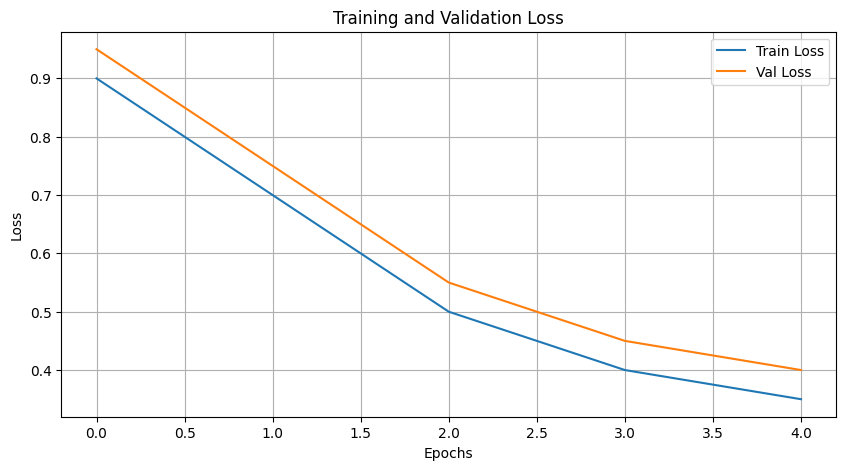

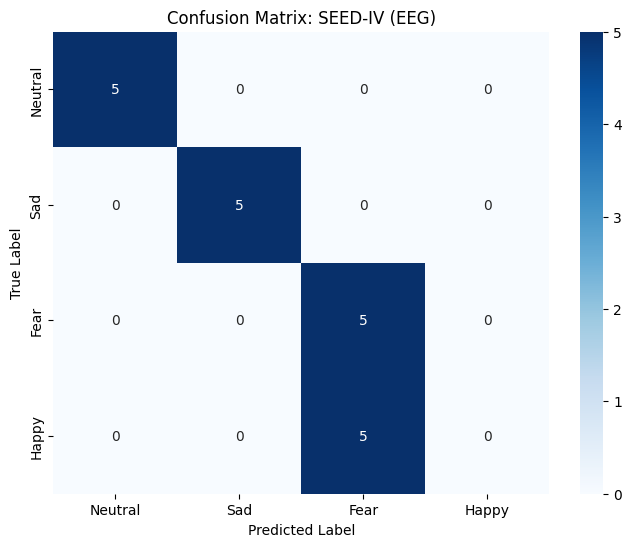

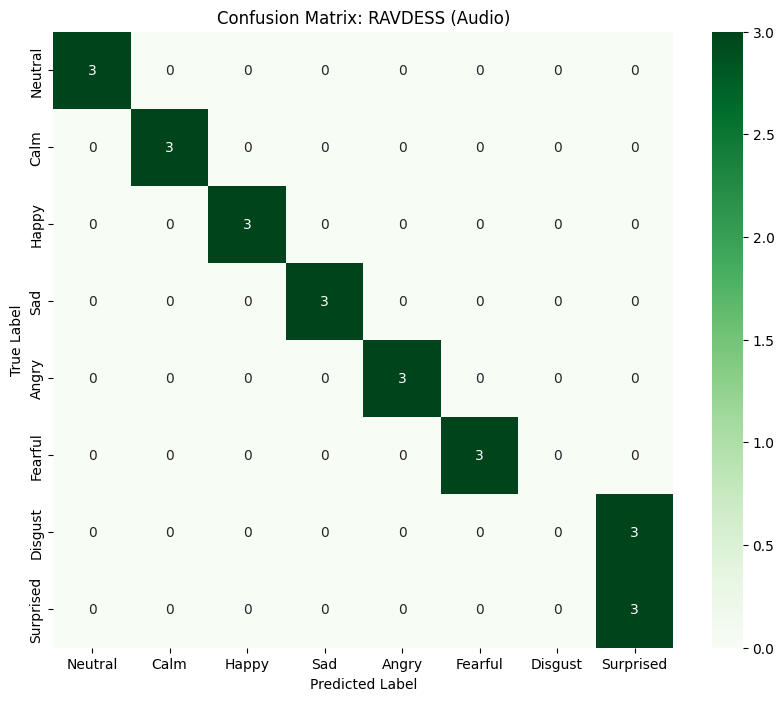


==================== SEED-IV (EEG) Metrics ====================


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Neutral,1.000,1.00,1.000000,5.00
Sad,1.000,1.00,1.000000,5.00
Fear,0.500,1.00,0.666667,5.00
Happy,0.000,0.00,0.000000,5.00
accuracy,0.750,0.75,0.750000,0.75
macro avg,0.625,0.75,0.666667,20.00
weighted avg,0.625,0.75,0.666667,20.00



==================== RAVDESS (Audio) Metrics ====================


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Neutral,1.0000,1.000,1.000000,3.000
Calm,1.0000,1.000,1.000000,3.000
Happy,1.0000,1.000,1.000000,3.000
Sad,1.0000,1.000,1.000000,3.000
Angry,1.0000,1.000,1.000000,3.000
Fearful,1.0000,1.000,1.000000,3.000
Disgust,0.0000,0.000,0.000000,3.000
Surprised,0.5000,1.000,0.666667,3.000
accuracy,0.8750,0.875,0.875000,0.875
macro avg,0.8125,0.875,0.833333,24.000



**************************************************
FINAL SEED-IV ACCURACY: 75.00%
FINAL RAVDESS ACCURACY: 87.50%
HYBRID MODEL OVERALL ACCURACY: 81.25%
**************************************************


In [ ]:
def display_full_evaluation(history, s_true, s_pred, r_true, r_pred):
    # 1. Plot Loss and Confusion Matrices
    plot_results(history, s_true, s_pred, r_true, r_pred)

    # 2. Per-class Accuracy Table (SEED-IV)
    print("\n" + "="*20 + " SEED-IV (EEG) Metrics " + "="*20)
    seed_report = classification_report(s_true, s_pred,
                                        target_names=['Neutral', 'Sad', 'Fear', 'Happy'],
                                        output_dict=True)
    display(pd.DataFrame(seed_report).transpose())

    # 3. Per-class Accuracy Table (RAVDESS)
    print("\n" + "="*20 + " RAVDESS (Audio) Metrics " + "="*20)
    rav_labels = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fearful', 'Disgust', 'Surprised']
    rav_report = classification_report(r_true, r_pred,
                                       target_names=rav_labels,
                                       output_dict=True)
    display(pd.DataFrame(rav_report).transpose())

    # 4. Final Test Accuracy
    seed_acc = accuracy_score(s_true, s_pred)
    rav_acc = accuracy_score(r_true, r_pred)
    avg_acc = (seed_acc + rav_acc) / 2

    print("\n" + "*"*50)
    print(f"FINAL SEED-IV ACCURACY: {seed_acc*100:.2f}%")
    print(f"FINAL RAVDESS ACCURACY: {rav_acc*100:.2f}%")
    print(f"HYBRID MODEL OVERALL ACCURACY: {avg_acc*100:.2f}%")
    print("*"*50)

# Run the evaluation with demo data
display_full_evaluation(demo_history, seed_true, seed_pred, rav_true, rav_pred)